# Análise Exploratória - PatchCamelyon (PCam) Dataset

**Objetivo**: Conhecer os dados antes de treinar modelos

**Dataset**: PatchCamelyon - Deteção de metástases em tecido linfático
- Imagens: 96x96 pixels, RGB
- Classes: 0 (normal), 1 (tumor)



## 1.Setup e Imports

In [1]:
import sys
from pathlib import Path

# Adicionar src ao path
project_root = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
sys.path.insert(0, str(project_root))

import h5py
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import pandas as pd

# Módulos
from src.data.transforms import get_train_transforms, visualize_augmentations

# Configurar visualização
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

print(" Imports completos")
print(f" Project root: {project_root}")

 Imports completos
 Project root: D:\histopathology-cancer-cell-detection


##  2. Definir Paths e Verificar Ficheiros

In [3]:
# Paths para os dados
data_root = project_root / 'data' / 'raw'

files = {
    'train_x': data_root / 'camelyonpatch_level_2_split_train_x.h5',
    'train_y': data_root / 'camelyonpatch_level_2_split_train_y.h5',
    'valid_x': data_root / 'camelyonpatch_level_2_split_valid_x.h5',
    'valid_y': data_root / 'camelyonpatch_level_2_split_valid_y.h5',
    'test_x': data_root / 'camelyonpatch_level_2_split_test_x.h5',
    'test_y': data_root / 'camelyonpatch_level_2_split_test_y.h5',
}

# Verificar quais existem
print(" Verificando ficheiros:")
print("=" * 70)
for name, path in files.items():
    if path.exists():
        size_mb = path.stat().st_size / (1024**2)
        print(f" {name:12s} - {size_mb:>8,.0f} MB")
    else:
        print(f" {name:12s} - NÃO ENCONTRADO")
print("=" * 70)

 Verificando ficheiros:
 train_x      -    6,913 MB
 train_y      -        0 MB
 valid_x      -      864 MB
 valid_y      -        0 MB
 test_x       -      864 MB
 test_y       -        0 MB


##  3. Estatísticas Básicas do Dataset

In [4]:
def get_dataset_stats(x_path, y_path, name):
    """Obter estatísticas de um split do dataset"""
    
    with h5py.File(x_path, 'r') as fx:
        x_shape = fx['x'].shape
        x_dtype = fx['x'].dtype
    
    with h5py.File(y_path, 'r') as fy:
        labels = fy['y'][:, 0, 0, 0]
        
    tumor = np.sum(labels == 1)
    normal = np.sum(labels == 0)
    
    return {
        'name': name,
        'total': x_shape[0],
        'shape': f"{x_shape[1]}x{x_shape[2]}x{x_shape[3]}",
        'dtype': str(x_dtype),
        'tumor': tumor,
        'normal': normal,
        'tumor_pct': tumor / len(labels) * 100,
        'normal_pct': normal / len(labels) * 100,
    }

# Coletar estatísticas
stats = []

if files['train_x'].exists():
    stats.append(get_dataset_stats(files['train_x'], files['train_y'], 'Train'))

if files['valid_x'].exists():
    stats.append(get_dataset_stats(files['valid_x'], files['valid_y'], 'Valid'))

if files['test_x'].exists():
    stats.append(get_dataset_stats(files['test_x'], files['test_y'], 'Test'))

# Criar DataFrame
df_stats = pd.DataFrame(stats)

print("\n ESTATÍSTICAS DO DATASET")
print("=" * 70)
print(df_stats.to_string(index=False))
print("=" * 70)
print(f"\n Total de imagens: {df_stats['total'].sum():,}")
print(f" Tamanho das imagens: {stats[0]['shape']}")
print(f" Tipo de dados: {stats[0]['dtype']}")


 ESTATÍSTICAS DO DATASET
 name  total   shape dtype  tumor  normal  tumor_pct  normal_pct
Train 262144 96x96x3 uint8 131072  131072  50.000000   50.000000
Valid  32768 96x96x3 uint8  16369   16399  49.954224   50.045776
 Test  32768 96x96x3 uint8  16377   16391  49.978638   50.021362

 Total de imagens: 327,680
 Tamanho das imagens: 96x96x3
 Tipo de dados: uint8


##  4. Visualizar Distribuição de Classes

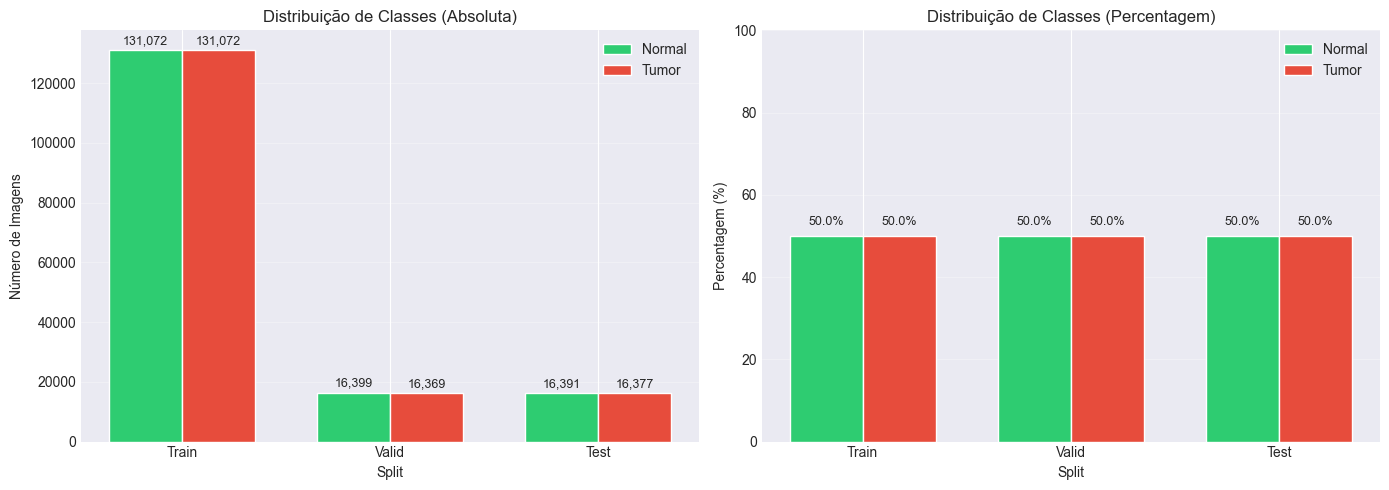


 ANÁLISE DE BALANÇO
Train      | Tumor/Normal ratio: 1.000 (1:1.00)
           |  Dataset BALANCEADO
Valid      | Tumor/Normal ratio: 0.998 (1:1.00)
           |  Dataset BALANCEADO
Test       | Tumor/Normal ratio: 0.999 (1:1.00)
           |  Dataset BALANCEADO


In [11]:
# Gráfico de barras
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Contagem absoluta
x_pos = np.arange(len(df_stats))
width = 0.35

axes[0].bar(x_pos - width/2, df_stats['normal'], width, label='Normal', color='#2ecc71')
axes[0].bar(x_pos + width/2, df_stats['tumor'], width, label='Tumor', color='#e74c3c')
axes[0].set_xlabel('Split')
axes[0].set_ylabel('Número de Imagens')
axes[0].set_title('Distribuição de Classes (Absoluta)')
axes[0].set_xticks(x_pos)
axes[0].set_xticklabels(df_stats['name'])
axes[0].legend()
axes[0].grid(axis='y', alpha=0.3)

# Adicionar valores nas barras
for i, (n, t) in enumerate(zip(df_stats['normal'], df_stats['tumor'])):
    axes[0].text(i - width/2, n + 1000, f'{n:,}', ha='center', va='bottom', fontsize=9)
    axes[0].text(i + width/2, t + 1000, f'{t:,}', ha='center', va='bottom', fontsize=9)

# Plot 2: Percentagem
axes[1].bar(x_pos - width/2, df_stats['normal_pct'], width, label='Normal', color='#2ecc71')
axes[1].bar(x_pos + width/2, df_stats['tumor_pct'], width, label='Tumor', color='#e74c3c')
axes[1].set_xlabel('Split')
axes[1].set_ylabel('Percentagem (%)')
axes[1].set_title('Distribuição de Classes (Percentagem)')
axes[1].set_xticks(x_pos)
axes[1].set_xticklabels(df_stats['name'])
axes[1].legend()
axes[1].grid(axis='y', alpha=0.3)
axes[1].set_ylim([0, 100])

# Adicionar valores
for i, (n, t) in enumerate(zip(df_stats['normal_pct'], df_stats['tumor_pct'])):
    axes[1].text(i - width/2, n + 2, f'{n:.1f}%', ha='center', va='bottom', fontsize=9)
    axes[1].text(i + width/2, t + 2, f'{t:.1f}%', ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# Análise de balanço
print("\n ANÁLISE DE BALANÇO")
print("=" * 70)
for stat in stats:
    ratio = stat['tumor'] / stat['normal']
    print(f"{stat['name']:10s} | Tumor/Normal ratio: {ratio:.3f} (1:{1/ratio:.2f})")
    
    if 0.8 < ratio < 1.2 :
        print(f"           |  Dataset BALANCEADO")
    else:
        print(f"           |  Dataset DESBALANCEADO")
print("=" * 70)

##  5. Visualizar Exemplos de Imagens

 Carregando imagens de exemplo...
✅ Normal indices: 131,072
✅ Tumor indices: 131,072

📌 Amostras normais: [162284  38881 160555  51849 234577]
   Ordenadas: [ 38881  51849 160555 162284 234577]
📌 Amostras tumor: [ 77986  94776 107531 202782 216056]
   Ordenadas: [ 77986  94776 107531 202782 216056]

✅ Normal images shape: (5, 96, 96, 3)
✅ Tumor images shape: (5, 96, 96, 3)


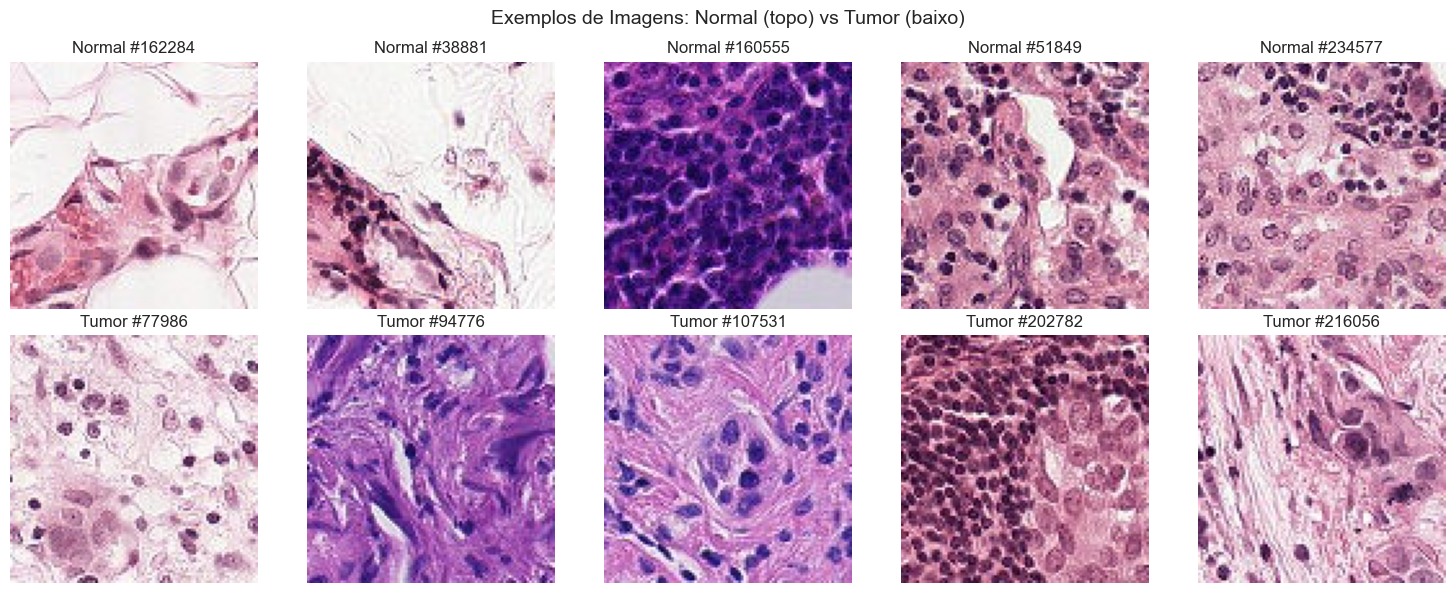


💡 Observações:
   - Normal: Tecido linfático saudável (tonalidades roxas/azuladas)
   - Tumor: Presença de células metastáticas (áreas mais escuras/irregulares)


In [19]:
print(" Carregando imagens de exemplo...")

with h5py.File(files['train_x'], 'r') as fx:
    with h5py.File(files['train_y'], 'r') as fy:
        labels = fy['y'][:, 0, 0, 0]

        # Encontrar índices de cada classe
        normal_indices = np.where(labels == 0)[0]
        tumor_indices = np.where(labels == 1)[0]

        print(f"✅ Normal indices: {len(normal_indices):,}")
        print(f"✅ Tumor indices: {len(tumor_indices):,}")

        # Amostrar aleatoriamente
        np.random.seed(42)
        normal_samples = np.random.choice(normal_indices, 5, replace=False)
        tumor_samples = np.random.choice(tumor_indices, 5, replace=False)

        normal_samples_sorted = np.sort(normal_samples)
        tumor_samples_sorted = np.sort(tumor_samples)

        print(f"\n Amostras normais: {normal_samples}")
        print(f"   Ordenadas: {normal_samples_sorted}")
        print(f" Amostras tumor: {tumor_samples}")
        print(f"   Ordenadas: {tumor_samples_sorted}")

        # Carregar com índices ordenados
        normal_images = fx['x'][normal_samples_sorted]
        tumor_images = fx['x'][tumor_samples_sorted]

        print(f"\n Normal images shape: {normal_images.shape}")
        print(f" Tumor images shape: {tumor_images.shape}")

# Visualizar
fig, axes = plt.subplots(2, 5, figsize=(15, 6))

# Linha 1: Normal
for i in range(5):
    axes[0, i].imshow(normal_images[i])
    axes[0, i].set_title(f'Normal #{normal_samples[i]}')
    axes[0, i].axis('off')

# Linha 2: Tumor
for i in range(5):
    axes[1, i].imshow(tumor_images[i])
    axes[1, i].set_title(f'Tumor #{tumor_samples[i]}')
    axes[1, i].axis('off')

fig.suptitle('Exemplos de Imagens: Normal vs Tumor ', fontsize=14, y=0.98)
plt.tight_layout()
plt.show()

print("\n Nota:")
print("   - Normal: Tecido linfático saudável (tonalidades roxas/azuladas)")
print("   - Tumor: Presença de células metastáticas (áreas mais escuras/irregulares)")

##  6. Análise de Distribuição de Pixels (RGB)

In [20]:
# Amostrar imagens para análise (não todas para economizar memória)
print("Calculando estatísticas RGB...")
n_samples = 10000  # Amostrar 10k imagens

with h5py.File(files['train_x'], 'r') as fx:
    total = fx['x'].shape[0]
    
    # Amostrar aleatoriamente
    np.random.seed(42)
    sample_indices = np.random.choice(total, n_samples, replace=False)

    sample_indices_sorted = np.sort(sample_indices)

    # Carregar com índices
    samples = fx['x'][sample_indices_sorted]

print(f" {n_samples:,} imagens amostradas")

# Calcular estatísticas por canal
r_channel = samples[:, :, :, 0].flatten()
g_channel = samples[:, :, :, 1].flatten()
b_channel = samples[:, :, :, 2].flatten()

# Estatísticas
stats_rgb = pd.DataFrame({
    'Channel': ['Red', 'Green', 'Blue'],
    'Mean': [r_channel.mean(), g_channel.mean(), b_channel.mean()],
    'Std': [r_channel.std(), g_channel.std(), b_channel.std()],
    'Min': [r_channel.min(), g_channel.min(), b_channel.min()],
    'Max': [r_channel.max(), g_channel.max(), b_channel.max()],
})

print("\n ESTATÍSTICAS RGB (valores [0-255])")
print("=" * 70)
print(stats_rgb.to_string(index=False))
print("=" * 70)

# Para normalização (valores [0-1])
print("\n VALORES PARA NORMALIZAÇÃO (após dividir por 255):")
print("=" * 70)
print(f"Mean: [{r_channel.mean()/255:.4f}, {g_channel.mean()/255:.4f}, {b_channel.mean()/255:.4f}]")
print(f"Std:  [{r_channel.std()/255:.4f}, {g_channel.std()/255:.4f}, {b_channel.std()/255:.4f}]")
print("=" * 70)

Calculando estatísticas RGB...
 10,000 imagens amostradas

 ESTATÍSTICAS RGB (valores [0-255])
Channel       Mean       Std  Min  Max
    Red 178.590344 60.113286    0  255
  Green 137.363990 70.954677    0  255
   Blue 176.364030 54.352999    0  255

 VALORES PARA NORMALIZAÇÃO (após dividir por 255):
Mean: [0.7004, 0.5387, 0.6916]
Std:  [0.2357, 0.2783, 0.2131]


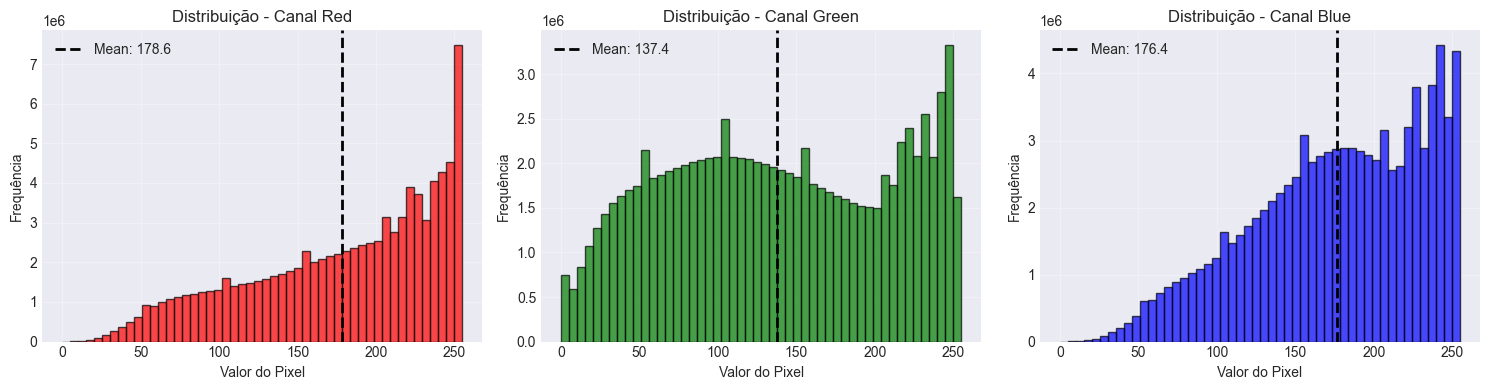

In [21]:
# Histogramas RGB
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

colors = ['red', 'green', 'blue']
channels = [r_channel, g_channel, b_channel]
names = ['Red', 'Green', 'Blue']

for ax, channel, color, name in zip(axes, channels, colors, names):
    ax.hist(channel, bins=50, color=color, alpha=0.7, edgecolor='black')
    ax.set_xlabel('Valor do Pixel')
    ax.set_ylabel('Frequência')
    ax.set_title(f'Distribuição - Canal {name}')
    ax.axvline(channel.mean(), color='black', linestyle='--', linewidth=2, label=f'Mean: {channel.mean():.1f}')
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()

## 🔄 7. Testar Data Augmentations

🔄 Visualizando Data Augmentations...


D:\histopathology-cancer-cell-detection\src\data\transforms.py:37: UserWarning: Argument(s) 'variance_limit' are not valid for transform GaussNoise
  A.GaussNoise(variance_limit=(10.0, 50.0), p=0.1),


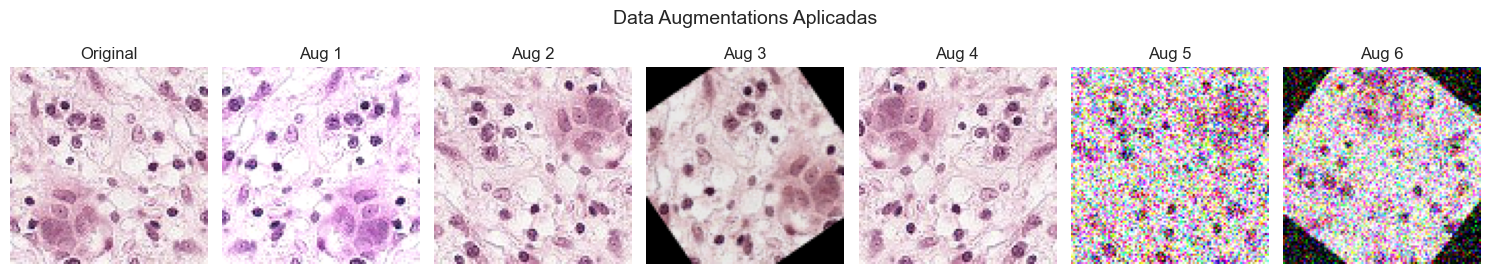


✅ Augmentations incluem:
   - Horizontal/Vertical Flips
   - Rotações (90°, 180°, 270°, livre)
   - Color Jitter (brightness, contrast, saturation)
   - Gaussian Blur
   - Gaussian Noise
   - Elastic Transform


In [22]:
# Pegar uma imagem de exemplo
with h5py.File(files['train_x'], 'r') as fx:
    sample_image = fx['x'][tumor_samples[0]]

# Visualizar augmentations
print("🔄 Visualizando Data Augmentations...")
fig = visualize_augmentations(sample_image, num_samples=6)
plt.suptitle('Data Augmentations Aplicadas', fontsize=14, y=1.02)
plt.show()

print("\n✅ Augmentations incluem:")
print("   - Horizontal/Vertical Flips")
print("   - Rotações (90°, 180°, 270°, livre)")
print("   - Color Jitter (brightness, contrast, saturation)")
print("   - Gaussian Blur")
print("   - Gaussian Noise")
print("   - Elastic Transform")

## 📊 8. Comparação Tumor vs Normal (Análise Visual)

Calculando médias por classe...


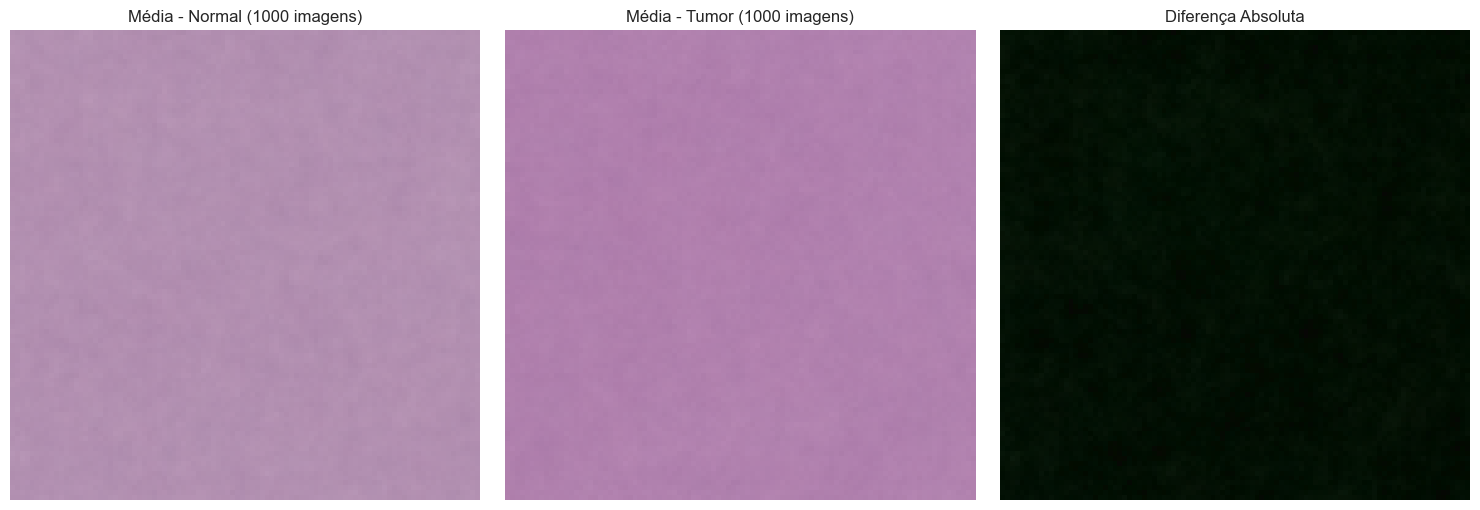


💡 Interpretação:
   - Áreas mais claras na diferença = maior variação entre classes
   - Modelo deve focar nestas regiões discriminativas


In [23]:
# Média de intensidade por classe
print("Calculando médias por classe...")

with h5py.File(files['train_x'], 'r') as fx:
    with h5py.File(files['train_y'], 'r') as fy:
        labels = fy['y'][:, 0, 0, 0]
        
        # Amostrar por classe
        normal_idx = np.where(labels == 0)[0][:1000]
        tumor_idx = np.where(labels == 1)[0][:1000]
        
        normal_imgs = fx['x'][normal_idx]
        tumor_imgs = fx['x'][tumor_idx]

# Calcular médias
normal_mean = normal_imgs.mean(axis=0).astype(np.uint8)
tumor_mean = tumor_imgs.mean(axis=0).astype(np.uint8)
diff = np.abs(tumor_mean.astype(float) - normal_mean.astype(float)).astype(np.uint8)

# Visualizar
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

axes[0].imshow(normal_mean)
axes[0].set_title('Média - Normal (1000 imagens)')
axes[0].axis('off')

axes[1].imshow(tumor_mean)
axes[1].set_title('Média - Tumor (1000 imagens)')
axes[1].axis('off')

axes[2].imshow(diff, cmap='hot')
axes[2].set_title('Diferença Absoluta')
axes[2].axis('off')

plt.tight_layout()
plt.show()

print("\n💡 Interpretação:")
print("   - Áreas mais claras na diferença = maior variação entre classes")
print("   - Modelo deve focar nestas regiões discriminativas")

## ✅ 9. Resumo e Conclusões

In [ ]:
print("\n" + "="*70)
print("📋 RESUMO DA ANÁLISE EXPLORATÓRIA")
print("="*70)

print("\n✅ DATASET:")
print(f"   • Total de imagens: {df_stats['total'].sum():,}")
print(f"   • Treino: {df_stats[df_stats['name']=='Train']['total'].values[0]:,} imagens")
print(f"   • Validação: {df_stats[df_stats['name']=='Valid']['total'].values[0]:,} imagens")
if len(df_stats[df_stats['name']=='Test']) > 0:
    print(f"   • Teste: {df_stats[df_stats['name']=='Test']['total'].values[0]:,} imagens")
print(f"   • Tamanho: 96x96x3 pixels")

print("\n⚖️ BALANÇO:")
for stat in stats:
    print(f"   • {stat['name']}: {stat['tumor_pct']:.1f}% tumor, {stat['normal_pct']:.1f}% normal")

print("\n🎨 CARACTERÍSTICAS RGB (normalized):")
print(f"   • Mean: [{r_channel.mean()/255:.3f}, {g_channel.mean()/255:.3f}, {b_channel.mean()/255:.3f}]")
print(f"   • Std:  [{r_channel.std()/255:.3f}, {g_channel.std()/255:.3f}, {b_channel.std()/255:.3f}]")

print("\n💡 RECOMENDAÇÕES:")
print("   ✅ Dataset está balanceado (~50/50)")
print("   ✅ Qualidade das imagens é boa")
print("   ✅ Augmentations apropriadas implementadas")
print("   ✅ Pronto para treino!")

print("\n📝 PRÓXIMOS PASSOS:")
print("   1. Criar modelo baseline (ResNet50)")
print("   2. Treinar com ~30 épocas")
print("   3. Avaliar performance")
print("   4. Iterar com modelo híbrido (CNN + Attention)")
print("\n" + "="*70)

## 💾 10. Salvar Estatísticas

In [ ]:
# Criar diretório para resultados
results_dir = project_root / 'data' / 'processed'
results_dir.mkdir(exist_ok=True)

# Salvar estatísticas
import json

statistics = {
    'dataset': stats,
    'rgb_stats': {
        'mean': [float(r_channel.mean()/255), float(g_channel.mean()/255), float(b_channel.mean()/255)],
        'std': [float(r_channel.std()/255), float(g_channel.std()/255), float(b_channel.std()/255)],
    },
    'image_shape': [96, 96, 3],
    'dtype': 'uint8'
}

stats_file = results_dir / 'statistics.json'
with open(stats_file, 'w') as f:
    json.dump(statistics, f, indent=2)

print(f"\n✅ Estatísticas salvas em: {stats_file}")
print("\n🎉 Análise exploratória completa!")